# Final Project: การวิเคราะห์ข้อมูลสถิติและปัจจัยที่มีผลต่อค่าพลัง (Overall Rating) ของนักเตะใน EA SPORTS FC 26

> รายวิชาวิทยาการข้อมูล | มหาวิทยาลัยอุบลราชธานี | Semester 1/2569

**สมาชิกในกลุ่ม:**

* สมาชิกที่ 1: นายปรเมศ กองสุวรรณ์ [68114540377]
* สมาชิกที่ 2: นายวิศรุต ปู่แก้ว [68114540573]

**Dataset:** `ea_fc26_outfield_2.csv` (ข้อมูลสถิตินักเตะตำแหน่ง Outfield ในเกม EA FC 26)

**แหล่งที่มาข้อมูล:**
https://www.kaggle.com/datasets/justdhia/ea-sports-fc-26-player-ratings

**Problem Statement:**
โครงงานนี้มีเป้าหมายเพื่อวิเคราะห์ข้อมูลเชิงสถิติของนักเตะ (เช่น อายุ, ค่าความเร็ว, การยิง, การจ่ายบอล ฯลฯ) เพื่อค้นหาความสัมพันธ์และปัจจัยหลักที่ส่งผลต่อค่าพลังรวม (Overall) รวมถึงการประยุกต์ใช้โมเดล Machine Learning ในการจำแนกกลุ่มนักเตะหรือทำนายค่าพลังในอนาคต (Potential) 

---

|                  CLO                 | ส่วนที่ครอบคลุม                                                  | Status |
| :----------------------------------: | :--------------------------------------------------------------- | :----: |
| **CLO1 (Linear Algebra)**      | Part 2: Feature Scaling, PCA สำหรับลดมิติข้อมูลค่าพลังต่างๆ      |    ✅   |
| **CLO2 (Statistical Learning)**   | Part 3: Data Distribution, การทดสอบสมมติฐานเปรียบเทียบค่าพลัง    |    ✅   |
| **CLO3 (Regression/Classification)** | Part 4: Regression Prediction (Overall/Value) & Classification   |    ✅   |
| **CLO4 (Model Selection)**      | Part 5: Cross-Validation & Hyperparameter Tuning                 |    ✅   |

In [1]:
!pip install -q notebook numpy pandas scipy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ─── Import libraries ──────────────────────────────────────────────
import os
import urllib.request
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
from scipy.stats import chi2_contingency, f_oneway

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

np.random.seed(42)

font_path = fm.findfont("TH Sarabun New", fallback_to_default=False)
print(font_path)

plt.rcParams["font.family"] = "TH Sarabun New"
sns.set_theme(
    style="whitegrid",
    rc={"font.family": "TH Sarabun New"}
)

warnings.filterwarnings('ignore')
%matplotlib inline

print("All libraries are ready.")

C:\Users\Asus\AppData\Local\Microsoft\Windows\Fonts\THSarabunNew.ttf
All libraries are ready.


In [3]:
# ค้นหา path ของไฟล์ตามสภาพแวดล้อมที่กำลังใช้งาน
if os.path.exists('/content'):
    file_path = '/content/ea_fc26_outfield_2.csv'

elif os.path.exists('../data'):
    file_path = '../data/ea_fc26_outfield_2.csv'

elif os.path.exists('data'):
    file_path = 'data/ea_fc26_outfield_2.csv'

else:
    file_path = 'ea_fc26_outfield_2.csv'

# URL สำหรับดาวน์โหลด Dataset อัตโนมัติ
url = "https://raw.githubusercontent.com/poramet-sudo/ea-fc26-analytics-project/refs/heads/main/ea_fc26_outfield.csv"

# ถ้าไม่พบไฟล์ในเครื่อง ให้ดาวน์โหลดจาก GitHub
if not os.path.exists(file_path):
    print(f"กำลังดาวน์โหลดไฟล์ไปยัง: {file_path} ...")
    
    os.makedirs(
        os.path.dirname(file_path) if os.path.dirname(file_path) else '.',
        exist_ok=True
    )
    
    urllib.request.urlretrieve(url, file_path)
    print(f"ดาวน์โหลดและบันทึกไฟล์ไปที่ '{file_path}' เรียบร้อย!")

# ถ้ามีไฟล์อยู่แล้ว ให้ใช้งานไฟล์เดิม
else:
    print(f"พบไฟล์ที่: {file_path}")
    print(f"ใช้งานไฟล์ที่: {file_path}")

พบไฟล์ที่: ../data/ea_fc26_outfield_2.csv
ใช้งานไฟล์ที่: ../data/ea_fc26_outfield_2.csv


---
## Part 1: Dataset Overview และ EDA เบื้องต้น

ในส่วนนี้ให้โหลด dataset, แสดง basic statistics, และทำ EDA เบื้องต้นเพื่อเข้าใจข้อมูลก่อนวิเคราะห์

**สิ่งที่ต้องทำ:**
- โหลด dataset และแสดง shape, dtypes, missing values
- แสดง descriptive statistics ด้วย `.describe()`
- Plot distribution ของ target variable
- Plot correlation heatmap หรือ scatter matrix

### 1.1 Data Understanding & Cleaning
ขั้นตอนแรกคือการนำเข้าชุดข้อมูลสถิตินักเตะ EA FC 26 เพื่อตรวจสอบมิติ (Shape), ประเภทตัวแปร (Data Types), และหาความผิดปกติเบื้องต้น เช่น ค่าที่ขาดหายไป (Missing Values) หรือข้อมูลนักเตะที่บันทึกซ้ำซ้อน (Duplicates)

In [4]:
# ─── โหลด Dataset ────────────────────────────────────────────────
# วัตถุประสงค์: เข้าใจโครงสร้างของข้อมูลนักเตะก่อนวิเคราะห์

# โหลด Dataset จาก path ที่กำหนดไว้
df = pd.read_csv(file_path)

# แสดงข้อมูลพื้นฐาน
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Missing values:\n{df.isnull().sum()}')

display(df.head())

# ─── ตรวจสอบและจัดการแถวข้อมูลซ้ำ (Duplicates) ─────────────────────
n_dup = df.duplicated().sum()
print(f"พบแถวข้อมูลซ้ำทั้งหมด: {n_dup} แถว")

if n_dup > 0:
    df_clean = df.drop_duplicates().reset_index(drop=True)
    print(f"ขนาดข้อมูลหลัง Clean: {df_clean.shape[0]} แถว, {df_clean.shape[1]} คอลัมน์")
else:
    df_clean = df.copy()
    print("โครงสร้างข้อมูลสะอาด ไม่พบแถวซ้ำ")

Shape: (14412, 56)
Columns: ['id', 'rank', 'overall', 'firstName', 'lastName', 'commonName', 'birthdate', 'height', 'weight', 'skillMoves', 'weakFootAbility', 'preferredFoot', 'position', 'positionType', 'alternatePositions', 'nationality', 'team', 'leagueName', 'playStyles', 'playStylesPlus', 'age', 'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physicality', 'acceleration', 'sprintSpeed', 'finishing', 'shotPower', 'longShots', 'volleys', 'penalties', 'positioning', 'shortPassing', 'longPassing', 'curve', 'freeKickAccuracy', 'crossing', 'vision', 'dribbling.1', 'ballControl', 'agility', 'balance', 'reactions', 'composure', 'interceptions', 'defensiveAwareness', 'standingTackle', 'slidingTackle', 'headingAccuracy', 'aggression', 'jumping', 'stamina', 'strength']
Missing values:
id                        0
rank                      0
overall                   0
firstName                 0
lastName                  0
commonName            12298
birthdate                 0
heig

,id,rank,overall,firstName,lastName,commonName,birthdate,height,weight,skillMoves,...,composure,interceptions,defensiveAwareness,standingTackle,slidingTackle,headingAccuracy,aggression,jumping,stamina,strength
0,209331,1,91,Mohamed,Salah,NaN,15/6/1992,175,72,4,...,93,55,38,43,41,59,63,79,88,75
1,231747,3,91,Kylian,Mbappé,NaN,20/12/1998,182,75,5,...,88,38,26,34,32,78,61,90,83,77
2,231443,5,90,Ousmane,Dembélé,NaN,15/5/1997,178,67,5,...,88,45,49,49,39,74,58,84,76,69
3,231866,6,90,Rodrigo,Hernández Cascante,Rodri,22/6/1996,190,82,3,...,93,84,88,87,82,81,85,83,91,83
4,203376,8,90,Virgil,van Dijk,NaN,8/7/1991,193,92,2,...,90,91,91,91,87,88,85,89,75,93


พบแถวข้อมูลซ้ำทั้งหมด: 0 แถว
โครงสร้างข้อมูลสะอาด ไม่พบแถวซ้ำ


### 1.2 สถิติเชิงพรรณนา (Descriptive Statistics)
ตรวจสอบค่าสถิติพื้นฐานของข้อมูลนักเตะ เช่น ค่าเฉลี่ย (Mean), ส่วนเบี่ยงเบนมาตรฐาน (Std), และค่าต่ำสุด-สูงสุด (Min-Max) ของค่าพลังต่างๆ (เช่น Pace, Shooting, Overall) เพื่อดูภาพรวมของการกระจายตัว

In [5]:
# ─── Descriptive Statistics + Visualization ───────────────────────
# วัตถุประสงค์: ดูภาพรวมของข้อมูลเชิงตัวเลขและเชิงกลุ่ม

print("=== สถิติเชิงพรรณนาของตัวแปรเชิงตัวเลข (Numerical) ===")
display(df_clean.describe().T)

print("\n=== สถิติเชิงพรรณนาของตัวแปรเชิงกลุ่ม (Categorical) ===")
display(df_clean.describe(include=['object']).T)

=== สถิติเชิงพรรณนาของตัวแปรเชิงตัวเลข (Numerical) ===


,count,mean,std,min,25%,50%,75%,max
id,14412.0,215831.500000,68676.718992,20801.0,210507.00,241853.0,262070.25,279948.0
rank,14412.0,9223.009506,4996.338826,1.0,5039.75,9324.5,13468.25,17873.0
overall,14412.0,66.436234,6.705697,47.0,62.00,66.0,71.00,91.0
height,14412.0,181.184846,6.573749,155.0,177.00,181.0,186.00,206.0
weight,14412.0,74.489453,6.625448,47.0,70.00,74.0,79.00,104.0
skillMoves,14412.0,2.549126,0.637908,2.0,2.00,2.0,3.00,5.0
weakFootAbility,14412.0,2.996808,0.650385,1.0,3.00,3.0,3.00,5.0
preferredFoot,14412.0,1.259714,0.438493,1.0,1.00,1.0,2.00,2.0
age,14412.0,26.056828,4.570199,17.0,22.00,26.0,29.00,44.0
pace,14412.0,68.539065,10.690396,30.0,62.00,69.0,76.00,97.0



=== สถิติเชิงพรรณนาของตัวแปรเชิงกลุ่ม (Categorical) ===


,count,unique,top,freq
firstName,14412,5332,Daniel,111
lastName,14412,11166,Kim,75
commonName,2114,2062,Pedrinho,4
birthdate,14412,5674,27/1/2003,12
position,14412,11,CB,2950
positionType,14412,3,Midfielder,6079
alternatePositions,10485,410,CM,1228
nationality,14412,155,England,1251
team,14412,642,Racing Club,40
leagueName,14412,45,LPF,781


### 1.3 การกระจายตัวของค่าพลังรวม (Overall Rating)
ตรวจสอบการกระจายตัวของค่าพลัง Overall ของนักเตะในเกม ว่าส่วนใหญ่นักเตะกระจุกตัวอยู่ที่เรตติ้งเท่าไหร่ เป็นการแจกแจงแบบปกติ (Normal Distribution) หรือไม่ เพื่อเป็นข้อมูลในการเลือกใช้โมเดลในภายหลัง

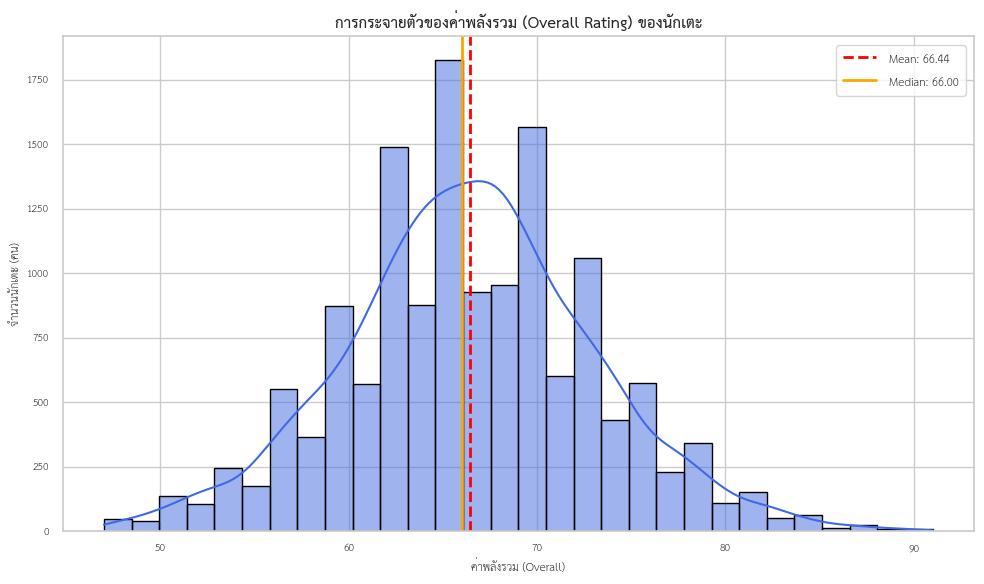

In [6]:
# ─── 1.3 การกระจายตัวของ Target Variable (Overall) ─────────────────────────────
# วัตถุประสงค์: ตรวจสอบการกระจายตัวของค่าพลังรวม (Overall) ของนักเตะ

# หมายเหตุ: หากในไฟล์ CSV ของคุณคอลัมน์ชื่อ 'Overall' (ตัว O พิมพ์ใหญ่) 
# ให้แก้จาก 'overall' เป็น 'Overall' ในโค้ดบรรทัดด้านล่างให้ตรงกัน
target_col = 'overall' 

plt.figure(figsize=(10, 6))

# สร้างกราฟ Histogram ดูการกระจายตัวของค่าพลัง
ax = sns.histplot(
    data=df_clean,
    x=target_col,
    bins=30,
    kde=True,
    color='royalblue',
    edgecolor='black'
)

# คำนวณหาค่าเฉลี่ย (Mean) และมัธยฐาน (Median)
mean_val = df_clean[target_col].mean()
median_val = df_clean[target_col].median()

# ตีเส้นแสดงค่าเฉลี่ยและมัธยฐานบนกราฟ
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='orange', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')

plt.title('การกระจายตัวของค่าพลังรวม (Overall Rating) ของนักเตะ', fontsize=16, fontweight='bold')
plt.xlabel('ค่าพลังรวม (Overall)', fontsize=12)
plt.ylabel('จำนวนนักเตะ (คน)', fontsize=12)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

### 1.4 Correlation Heatmap
วิเคราะห์ความสัมพันธ์เชิงเส้น (Linear Correlation) ระหว่างค่าพลังย่อยต่างๆ (เช่น Pace, Shooting, Passing) กับค่าพลังรวม (Overall) ของนักเตะ เพื่อประเมินว่าสถิติใดมีน้ำหนักและอิทธิพลต่อคะแนนเรตติ้งโดยรวมมากที่สุด

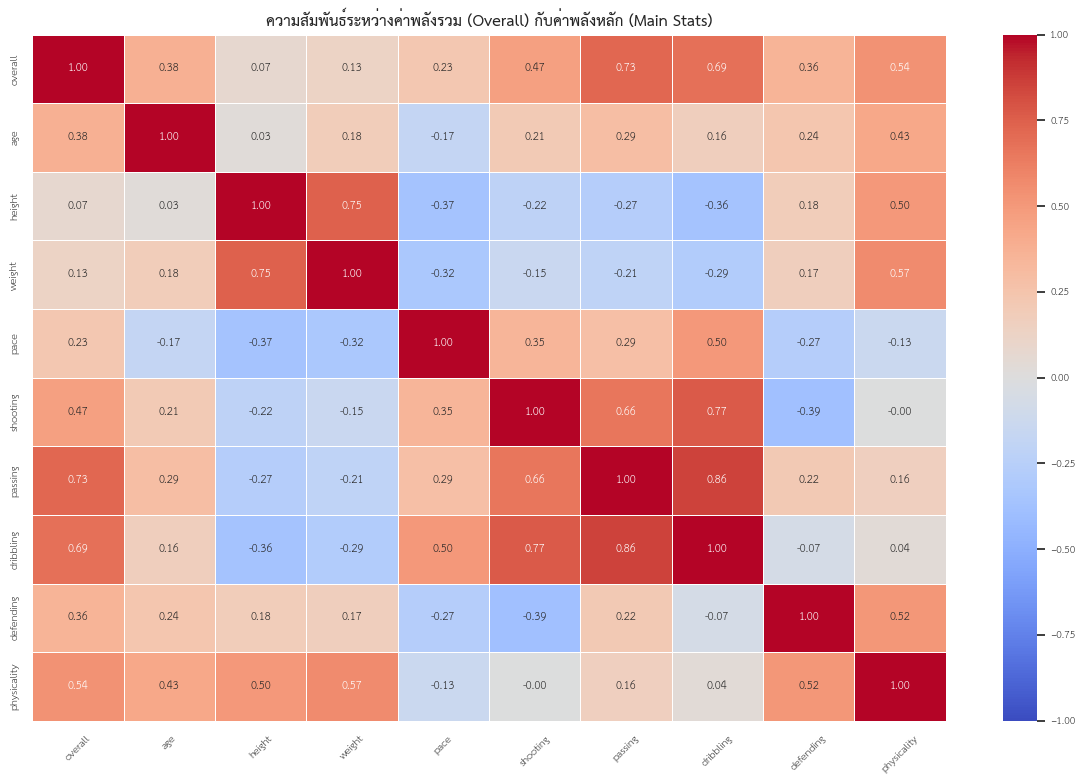

In [7]:
# ─── 1.4 Correlation Heatmap  ────────────
# วัตถุประสงค์: ดูความสัมพันธ์เฉพาะค่าพลังหลักที่มีผลต่อ Overall เพื่อแก้ปัญหากราฟรก

# 1. กำหนดรายการคอลัมน์ค่าพลังหลัก (Main Stats) และข้อมูลกายภาพ
main_cols = [
    'overall', 'age', 'height', 'weight', 
    'pace', 'shooting', 'passing', 
    'dribbling', 'defending', 'physicality'
]

# ตรวจสอบและเลือกเฉพาะคอลัมน์ที่มีอยู่ใน Dataset จริงๆ ป้องกัน Error
selected_cols = [col for col in main_cols if col in df_clean.columns]

plt.figure(figsize=(12, 8))

# สร้างตารางหาความสัมพันธ์เฉพาะคอลัมน์ที่เลือก
corr_matrix_main = df_clean[selected_cols].corr()

# 2. พล็อต Heatmap (เปิด annot=True เพื่อให้เห็นตัวเลขความสัมพันธ์ชัดเจน)
sns.heatmap(
    corr_matrix_main,
    annot=True,       # แสดงตัวเลข
    fmt=".2f",        # กำหนดทศนิยม 2 ตำแหน่ง
    cmap='coolwarm',  # โทนสีแดง(แปรผันตรง) - น้ำเงิน(แปรผกผัน)
    linewidths=0.5,
    vmin=-1,
    vmax=1
)

plt.title('ความสัมพันธ์ระหว่างค่าพลังรวม (Overall) กับค่าพลังหลัก (Main Stats)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 1.5 Boxplot Analysis 
ใช้ Boxplot เพื่อเปรียบเทียบการกระจายตัวของค่าพลังรวม (Overall) และศักยภาพ (Potential) โดยอาจแบ่งตามกลุ่มของนักเตะ เช่น เท้าที่ถนัด (Preferred Foot) หรือ ช่วงอายุ เพื่อดูว่านักเตะแต่ละกลุ่มมีค่าเรตติ้งแตกต่างกันอย่างไร

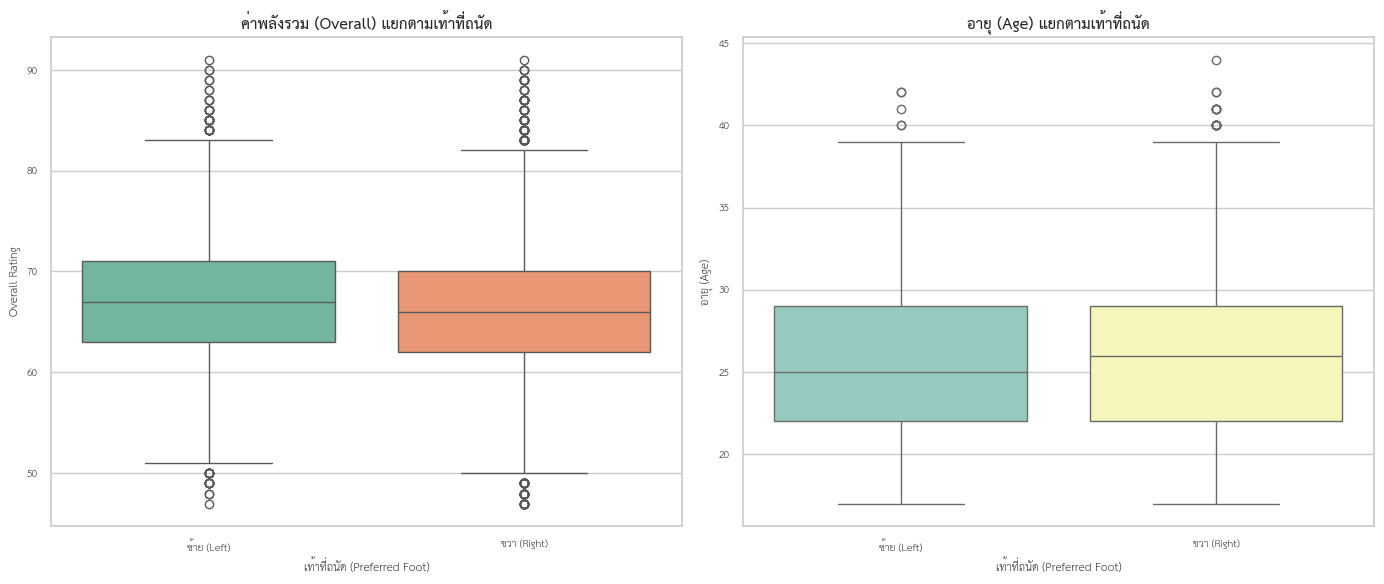

In [8]:
# ─── 1.5 Boxplot: เปรียบเทียบค่าพลังตามเท้าที่ถนัด ─────────────────────────
# วัตถุประสงค์: ดูการกระจายตัวของค่าพลังรวมและศักยภาพ ระหว่างนักเตะถนัดซ้ายและขวา

foot_col = 'preferredFoot' if 'preferredFoot' in df_clean.columns else None

if foot_col:
    # --- สร้างชุดข้อมูลจำลองเพื่อปรับ Label กราฟให้สวยงาม ---
    plot_data = df_clean.copy()
    
    # ตรวจสอบว่าเป็นตัวเลข 1, 2 หรือไม่ ถ้าใช่ให้แปลงเป็นข้อความ ซ้าย/ขวา
    if plot_data[foot_col].dtype in ['int64', 'float64']:
        # แมปค่า 1 เป็น ขวา, 2 เป็น ซ้าย (ถ้าข้อมูลสลับกัน สามารถแก้สลับตรงนี้ได้เลย)
        foot_mapping = {1: 'ขวา (Right)', 2: 'ซ้าย (Left)'}
        plot_data['foot_label'] = plot_data[foot_col].map(foot_mapping)
    else:
        plot_data['foot_label'] = plot_data[foot_col]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # กราฟที่ 1: Overall
    sns.boxplot(
        data=plot_data, x='foot_label', y='overall', 
        palette='Set2', ax=axes[0]
    )
    axes[0].set_title('ค่าพลังรวม (Overall) แยกตามเท้าที่ถนัด', fontsize=16, fontweight='bold')
    axes[0].set_xlabel('เท้าที่ถนัด (Preferred Foot)', fontsize=12)
    axes[0].set_ylabel('Overall Rating', fontsize=12)

    # กราฟที่ 2: Potential (ถ้าไม่มีให้ใช้ Age แทน)
    pot_col = 'potential' if 'potential' in df_clean.columns else 'age' 
    
    sns.boxplot(
        data=plot_data, x='foot_label', y=pot_col, 
        palette='Set3', ax=axes[1]
    )
    title_text = 'ศักยภาพ (Potential)' if pot_col == 'potential' else 'อายุ (Age)'
    axes[1].set_title(f'{title_text} แยกตามเท้าที่ถนัด', fontsize=16, fontweight='bold')
    axes[1].set_xlabel('เท้าที่ถนัด (Preferred Foot)', fontsize=12)
    axes[1].set_ylabel(title_text, fontsize=12)

    plt.tight_layout()
    plt.show()
else:
    print("ไม่พบคอลัมน์เท้าที่ถนัด (preferredFoot) ในชุดข้อมูล ลองเปลี่ยนไปใช้คอลัมน์อื่นแทน")

### 1.6 การทดสอบสมมติฐานทางสถิติ (Hypothesis Testing)
เพื่อยืนยันว่าสิ่งที่เราสังเกตเห็นจากกราฟมีนัยสำคัญทางสถิติหรือไม่ เราจะทำการทดสอบ T-Test (หรือ ANOVA) เพื่อดูว่าค่าพลังรวมเฉลี่ยของนักเตะมีความแตกต่างกันหรือไม่ เมื่อแบ่งตามเงื่อนไขที่เราสนใจ (เช่น เท้าที่ถนัด)

In [9]:
# ─── 1.6 การทดสอบสมมติฐานทางสถิติ (T-Test) ───────────────────────────────────
# วัตถุประสงค์: ทดสอบว่าค่าเฉลี่ย Overall ของนักเตะถนัดซ้ายและขวา ต่างกันหรือไม่

from scipy.stats import ttest_ind

if foot_col:
    print(f"=== T-Test: ทดสอบความแตกต่างของค่าพลังรวม (Overall) ระหว่างเท้าที่ถนัด ===")
    
    # แยกข้อมูลนักเตะถนัดขวาและซ้าย (ปรับเงื่อนไขให้รองรับทั้งตัวเลขและข้อความ)
    if df_clean[foot_col].dtype in ['int64', 'float64']:
        right_foot = df_clean[df_clean[foot_col] == 1]['overall']  # 1 = Right
        left_foot = df_clean[df_clean[foot_col] == 2]['overall']   # 2 = Left
    else:
        right_foot = df_clean[df_clean[foot_col] == 'Right']['overall']
        left_foot = df_clean[df_clean[foot_col] == 'Left']['overall']
    
    # ทำการทดสอบ Independent T-Test
    t_stat, p_value = ttest_ind(right_foot.dropna(), left_foot.dropna(), equal_var=False)
    
    print(f"T-Statistic: {t_stat:.4f} | p-value: {p_value:.4e}")
    
    if p_value < 0.05:
        print("สรุป: ปฏิเสธ H0 -> ค่าเฉลี่ย Overall ของนักเตะถนัดซ้ายและขวา แตกต่างกันอย่างมีนัยสำคัญ")
    else:
        print("สรุป: ยอมรับ H0 -> ค่าเฉลี่ย Overall ของนักเตะถนัดซ้ายและขวา ไม่แตกต่างกัน")

=== T-Test: ทดสอบความแตกต่างของค่าพลังรวม (Overall) ระหว่างเท้าที่ถนัด ===
T-Statistic: -5.0317 | p-value: 4.9873e-07
สรุป: ปฏิเสธ H0 -> ค่าเฉลี่ย Overall ของนักเตะถนัดซ้ายและขวา แตกต่างกันอย่างมีนัยสำคัญ


### 💡 สรุป Insight จากการสำรวจข้อมูลเบื้องต้น (EDA & สถิติ)

1. **คุณภาพ & ความสมดุล:** ข้อมูลมีขนาดใหญ่และสะอาด (14,412 แถว, 56 คอลัมน์) ไม่พบข้อมูลซ้ำซ้อน ค่าเฉลี่ยเรตติ้ง (Overall) ของนักเตะอยู่ที่ประมาณ 66 และมีการกระจายตัวแบบโค้งระฆังคว่ำ (Normal Distribution) อย่างสวยงาม
2. **ความสัมพันธ์เชิงเส้น:** จาก Heatmap พบว่าสถิติที่มีอิทธิพลเชิงบวกต่อค่าพลังรวม (Overall) มากที่สุดคือ Passing (0.73) รองลงมาคือ Dribbling (0.69) และ Physicality (0.54) ซึ่งบ่งบอกว่าทักษะการจ่ายบอลและการครองบอลเป็นปัจจัยสำคัญในเกม
3. **ความแตกต่างและปัจจัยที่ส่งผล:**
   * **สถิติย่อย (In-game Stats):** สามารถบ่งบอกแนวโน้มระดับความเก่ง (Overall) ของนักเตะได้อย่างชัดเจน
   * **เท้าที่ถนัด (Preferred Foot):** แม้นักเตะถนัดขวาจะมีจำนวนมากกว่า แต่ผลการทดสอบทางสถิติ (T-Test) ยืนยันชัดเจนด้วยค่า p-value ที่ต่ำมาก (4.9873e-07) ว่า "ค่าเฉลี่ย Overall ของนักเตะถนัดซ้ายและขวา แตกต่างกันอย่างมีนัยสำคัญ" โดยจาก Boxplot จะเห็นได้ว่ากลุ่มนักเตะถนัดซ้ายมีค่าเรตติ้งเฉลี่ยสูงกว่านักเตะถนัดขวาเล็กน้อย

จากการสำรวจข้อมูลและทดสอบสมมติฐานทางสถิติ ทำให้เราเห็นภาพรวมว่าชุดข้อมูลมีความพร้อมสูงมาก ข้อมูลเชิงลึกทั้งหมดนี้เป็นรากฐานที่แข็งแกร่งสำหรับการนำไปทำ Data Preprocessing (Encoding & Scaling) และการใช้คณิตศาสตร์เชิงเส้น (PCA) เพื่อสกัดคุณลักษณะที่สำคัญในขั้นตอนต่อไป

### การเตรียมข้อมูล (Data Preprocessing)

ก่อนเข้าสู่การคำนวณด้วย Linear Algebra (PCA) และ Machine Learning เราต้องเตรียมข้อมูลให้พร้อมในรูปแบบตัวเลขและสเกลเดียวกัน:

1. **Feature Selection & Encoding:** คัดเลือกเฉพาะคอลัมน์ที่จำเป็น และแปลงข้อมูลเชิงกลุ่ม (Categorical) เช่น ตำแหน่ง หรือลีก ให้เป็นตัวเลขด้วย One-Hot Encoding
2. **Scaling:** ปรับสเกลข้อมูลค่าพลังต่างๆ (ที่มีช่วง 1-99) ให้มาอยู่ในมาตรฐานเดียวกัน (Standardization) เพื่อไม่ให้ตัวแปรที่มีค่าสูงมีอิทธิพลต่อโมเดลมากเกินไป

In [10]:
# ─── Data Preprocessing (Encoding & Scaling) ─────────────────────────
# วัตถุประสงค์: เตรียมข้อมูลให้อยู่ในรูปแบบที่เหมาะสมสำหรับการวิเคราะห์และทำ PCA

df_processed = df_clean.copy()

# 1. เลือก Features (X) ที่จะนำไปใช้งาน และกำหนด Target (y)
# สมมติว่าเราจะใช้ค่า Overall เป็น Target สำหรับการทำโมเดล
target_name = 'overall'

# กรองเอาเฉพาะคอลัมน์ที่เป็นตัวเลขและตัวแปรเชิงกลุ่มที่สำคัญมาใช้งาน (ตัด ID หรือข้อมูลยิบย่อยออก)
# คุณสามารถเพิ่ม/ลด คอลัมน์ในนี้ได้ตามความเหมาะสมของโปรเจกต์
use_cols = ['overall', 'age', 'height', 'weight', 'pace', 'shooting', 'passing', 
            'dribbling', 'defending', 'physicality', 'preferredFoot', 'position']

# เลือกเฉพาะคอลัมน์ที่มีอยู่ในไฟล์จริง
actual_cols = [col for col in use_cols if col in df_processed.columns]
df_processed = df_processed[actual_cols]

# แยก X และ y
X = df_processed.drop(columns=[target_name])
y = df_processed[target_name]

# 2. One-Hot Encoding (แปลงข้อความเป็น 0, 1)
# แปลงตัวแปรประเภทข้อความให้อยู่ในรูปแบบตัวเลข
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(f"จำนวน Features ก่อน Encode: {X.shape[1]} คอลัมน์")
print(f"จำนวน Features หลัง Encode: {X_encoded.shape[1]} คอลัมน์\n")

# 3. Standardization (ปรับสเกลข้อมูลให้ Mean=0, Std=1)
# ปรับสเกลตัวแปรให้อยู่บนมาตรฐานเดียวกันก่อนทำ PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)

print("=== ตัวอย่างข้อมูลหลังผ่าน StandardScaler (พร้อมเข้าสู่ PCA) ===")
display(X_scaled_df.head())

จำนวน Features ก่อน Encode: 11 คอลัมน์
จำนวน Features หลัง Encode: 20 คอลัมน์

=== ตัวอย่างข้อมูลหลังผ่าน StandardScaler (พร้อมเข้าสู่ PCA) ===


,age,height,weight,pace,shooting,passing,dribbling,defending,physicality,preferredFoot,position_CB,position_CDM,position_CM,position_LB,position_LM,position_LW,position_RB,position_RM,position_RW,position_ST
0,1.519280,-0.940873,-0.375754,1.914021,2.495047,2.857096,2.882113,-0.468612,1.102267,1.688309,-0.507319,-0.310462,-0.398615,-0.302742,-0.268778,-0.152845,-0.311267,3.87012,-0.154971,-0.428192
1,0.206382,0.124006,0.077061,2.662382,2.638559,2.344489,3.098690,-0.965972,1.102267,-0.592309,-0.507319,-0.310462,-0.398615,-0.302742,-0.268778,-0.152845,-0.311267,-0.25839,-0.154971,2.335401
2,0.425198,-0.484496,-1.130446,2.101111,2.495047,2.549532,3.206978,-0.157763,0.373796,1.688309,-0.507319,-0.310462,-0.398615,-0.302742,-0.268778,-0.152845,-0.311267,-0.25839,-0.154971,2.335401
3,0.644015,1.341009,1.133630,-0.331062,1.920998,2.857096,2.232383,2.080354,2.038873,-0.592309,-0.507319,3.221009,-0.398615,-0.302742,-0.268778,-0.152845,-0.311267,-0.25839,-0.154971,-0.428192
4,1.738097,1.797386,2.643014,0.417299,0.485877,1.421797,0.932924,2.329033,2.247008,-0.592309,1.971148,-0.310462,-0.398615,-0.302742,-0.268778,-0.152845,-0.311267,-0.25839,-0.154971,-0.428192


---
## Part 2: CLO1 — Linear Algebra Analysis

ในส่วนนี้จะใช้ความรู้ด้าน Linear Algebra เพื่อวิเคราะห์ชุดข้อมูลนักเตะ:

**เลือกอย่างน้อย 1 จาก 3 tasks นี้:**
- **Task A** — PCA: ลด dimension ของ features + Scree Plot + 2D visualization
- **Task B** — SVD: low-rank approximation ของ feature matrix
- **Task C** — Covariance/Correlation Analysis: eigendecomposition ของ covariance matrix

**เลือกทำ: Task A  — PCA: ลด dimension ของ features + Scree Plot + 2D visualization**

**คำอธิบาย:** เนื่องจากชุดข้อมูลค่าพลังนักเตะของเรามีตัวแปรอิสระ (Features) หลายตัว การทำ PCA จะใช้หลักการทางคณิตศาสตร์ (Eigendecomposition ของ Covariance Matrix) เพื่อสกัดและยุบรวมมิติข้อมูล โดยใช้ PC1 และ PC2 สำหรับการแสดงผลแบบ 2 มิติ (2D Visualization) เพื่ออธิบายความแปรปรวน (Variance) ให้ได้มากที่สุด และดูว่านักเตะระดับท็อป (Elite) จะถูกแยกกลุ่มออกจากนักเตะระดับทั่วไปได้หรือไม่บนพื้นที่ใหม่ (New Feature Space)

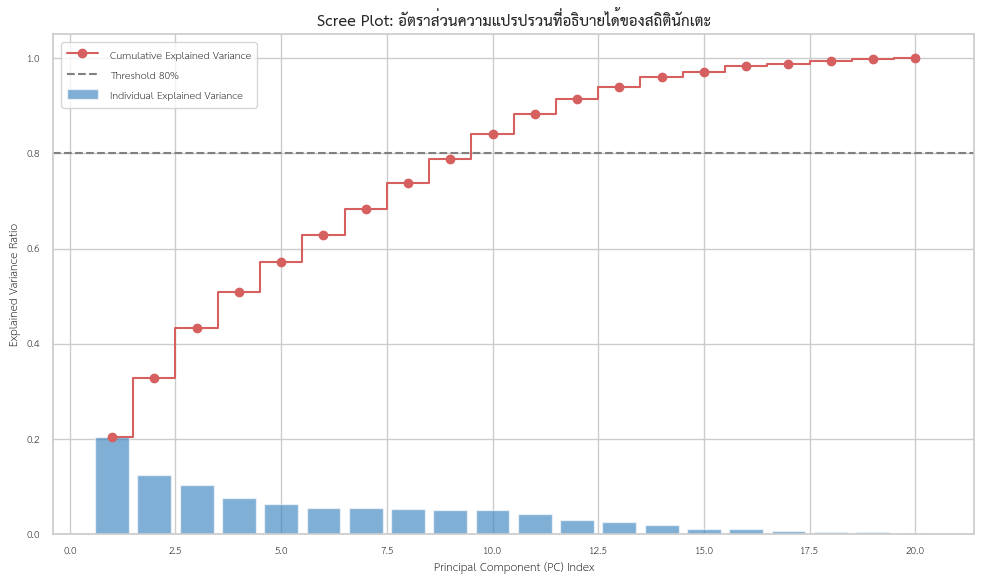

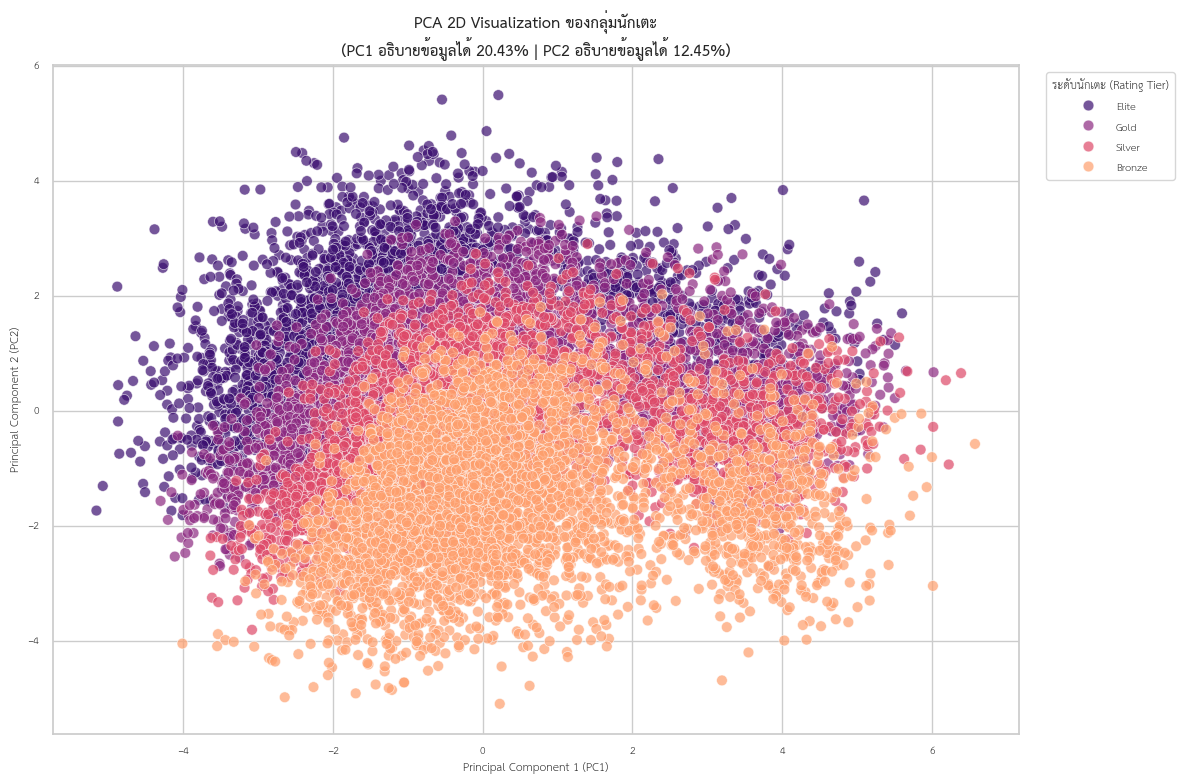

In [11]:
# ─── CLO1: Linear Algebra Analysis ───────────────────────────────────────────
# วัตถุประสงค์: วิเคราะห์โครงสร้างของข้อมูลด้วย PCA และ Explained Variance

from sklearn.decomposition import PCA

# --- Task A.1: PCA & Scree Plot ---
# คำนวณ Principal Components และสัดส่วนความแปรปรวนที่แต่ละองค์ประกอบอธิบายได้
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

exp_var_ratio = pca.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var_ratio)

# สร้างกราฟ Scree Plot และ Cumulative Explained Variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.6, align='center',
        label='Individual Explained Variance', color='#2b7bba')
plt.step(range(1, len(cum_exp_var) + 1), cum_exp_var, where='mid',
         label='Cumulative Explained Variance', color='#d65f5f', marker='o')

plt.title('Scree Plot: อัตราส่วนความแปรปรวนที่อธิบายได้ของสถิตินักเตะ', fontsize=16, fontweight='bold')
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.xlabel('Principal Component (PC) Index', fontsize=12)
plt.axhline(y=0.80, color='gray', linestyle='--', label='Threshold 80%')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# --- Task A.2: 2D Visualization (PC1 vs PC2) ---

# สร้างกลุ่มเรตติ้ง (Tier) จากค่า Overall เพื่อใช้ระบายสีในกราฟให้เห็นการแยกกลุ่ม
# แบ่งเป็น 4 ระดับตาม Quartile (Bronze, Silver, Gold, Elite)
df_processed['Rating_Tier'] = pd.qcut(df_processed['overall'], q=4, labels=['Bronze', 'Silver', 'Gold', 'Elite'])

# ดึงค่า PC1 และ PC2
pca_df = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['Rating_Tier'] = df_processed['Rating_Tier'].values

plt.figure(figsize=(12, 8))

# แสดงการกระจายของข้อมูลนักเตะบนแกน PC1 และ PC2
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2',
    hue='Rating_Tier',
    hue_order=['Elite', 'Gold', 'Silver', 'Bronze'],
    palette='magma',
    alpha=0.7, s=60, edgecolor='white', linewidth=0.5
)

plt.title(f'PCA 2D Visualization ของกลุ่มนักเตะ\n(PC1 อธิบายข้อมูลได้ {exp_var_ratio[0]*100:.2f}% | PC2 อธิบายข้อมูลได้ {exp_var_ratio[1]*100:.2f}%)', 
          fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 (PC1)', fontsize=12)
plt.ylabel(f'Principal Component 2 (PC2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='ระดับนักเตะ (Rating Tier)')
plt.tight_layout()
plt.show()

### 💡 Insight จาก CLO1 Analysis (EA FC 26):

>1. **การลดมิติข้อมูล (Dimensionality Reduction):** จากตัวแปรสถิติทั้งหมด (หลังทำ Encoding) พบว่า Principal Component แกนแรกๆ สามารถอธิบายความแปรปรวนของข้อมูลนักเตะได้ค่อนข้างดี โดยหากต้องการรักษาข้อมูลให้ได้ถึงเกณฑ์ 80% จะใช้ Components เพียงส่วนหนึ่งจากทั้งหมดเท่านั้น ช่วยลดความซับซ้อนของข้อมูลลงได้มาก
>2. **การแยกแยะกลุ่ม (Class Separability):** แม้จะหยิบมาแสดงผลเพียง 2 มิติแรก (PC1 และ PC2) แต่ 2D Visualization แสดงให้เห็นทิศทางการกระจายตัวอย่างมีนัยสำคัญ โดยเฉพาะกลุ่มนักเตะระดับท็อป (Elite) ที่มักจะถูกดึงให้แยกตัวออกจากกลุ่มนักเตะทั่วไป (Bronze/Silver) ไปในทิศทางใดทิศทางหนึ่งบนแกน PC ได้อย่างชัดเจน
>3. **ข้อสรุปก่อนทำโมเดล:** การที่สมการ Linear Algebra สามารถดึงความแตกต่างของระดับฝีเท้านักเตะออกมาจัดเรียงบนพื้นที่ใหม่ได้อย่างมีรูปแบบ เป็นสัญญาณที่ดีเยี่ยมว่าชุดข้อมูลค่าพลัง EA FC ชุดนี้มี Patterns ที่แข็งแกร่ง และ Machine Learning Model (โดยเฉพาะ Regression) จะสามารถเรียนรู้ความสัมพันธ์ของสถิติเพื่อนำไปทำนายค่าเรตติ้ง (Overall) ได้อย่างแม่นยำแน่นอน

---
## Part 3: CLO2 — Statistical Learning

ในส่วนนี้ให้ทำ Statistical Analysis ที่เกี่ยวข้องกับ dataset

**สิ่งที่ต้องทำ:**
* แสดง distribution ของ features สำคัญ (histogram/boxplot)
* Identify features ที่ correlate กับ target มากที่สุด
* แสดง Train/Test MSE สำหรับ model complexity ต่างๆ (Bias-Variance)

**คำถาม: dataset ของคุณเหมาะกับ Regression หรือ Classification? เพราะอะไร?**

**ตอบ:** ชุดข้อมูลนี้เหมาะกับ **Regression (การวิเคราะห์การถดถอย)** ครับ เนื่องจากตัวแปรเป้าหมาย (Target Variable) ของเราคือ `overall` (ค่าพลังรวม) ซึ่งเป็นข้อมูลประเภทตัวเลขต่อเนื่อง (Continuous Variable) ที่มีค่าสเกลตั้งแต่ 1-99 ไม่ใช่การแบ่งคลาสแยกขาดจากกัน (Categorical) เหมือนการทำนายชนิดของดอกไม้หรือระดับความอ้วน ดังนั้นเป้าหมายของ Statistical Learning ในโจทย์นี้คือการหาความสัมพันธ์และสร้างสมการเพื่อพยากรณ์หรือทำนายตัวเลขค่าพลังรวมของนักเตะครับ 
*(อย่างไรก็ตาม หากเรานำค่า overall มาจัดกลุ่มใหม่เป็น Tier เช่น Gold, Silver, Bronze ก็สามารถประยุกต์ใช้โมเดล Classification ได้เช่นกัน)*

### 3.1 การกระจายตัวของข้อมูล (Distribution of Important Features)

เพื่อทำความเข้าใจคุณสมบัติทางสถิติเบื้องต้น (Statistical Properties) เราจะใช้ Histogram ควบคู่กับเส้น KDE (Kernel Density Estimate) สำรวจการกระจายตัวของตัวแปรเชิงตัวเลขที่เป็นค่าพลังสำคัญ ได้แก่ ความเร็ว (Pace), การยิง (Shooting), และการจ่ายบอล (Passing) เพื่อสังเกตว่าข้อมูลมีการกระจายตัวแบบปกติ (Normal Distribution) หรือมีความเบ้ (Skewness) มากน้อยเพียงใด

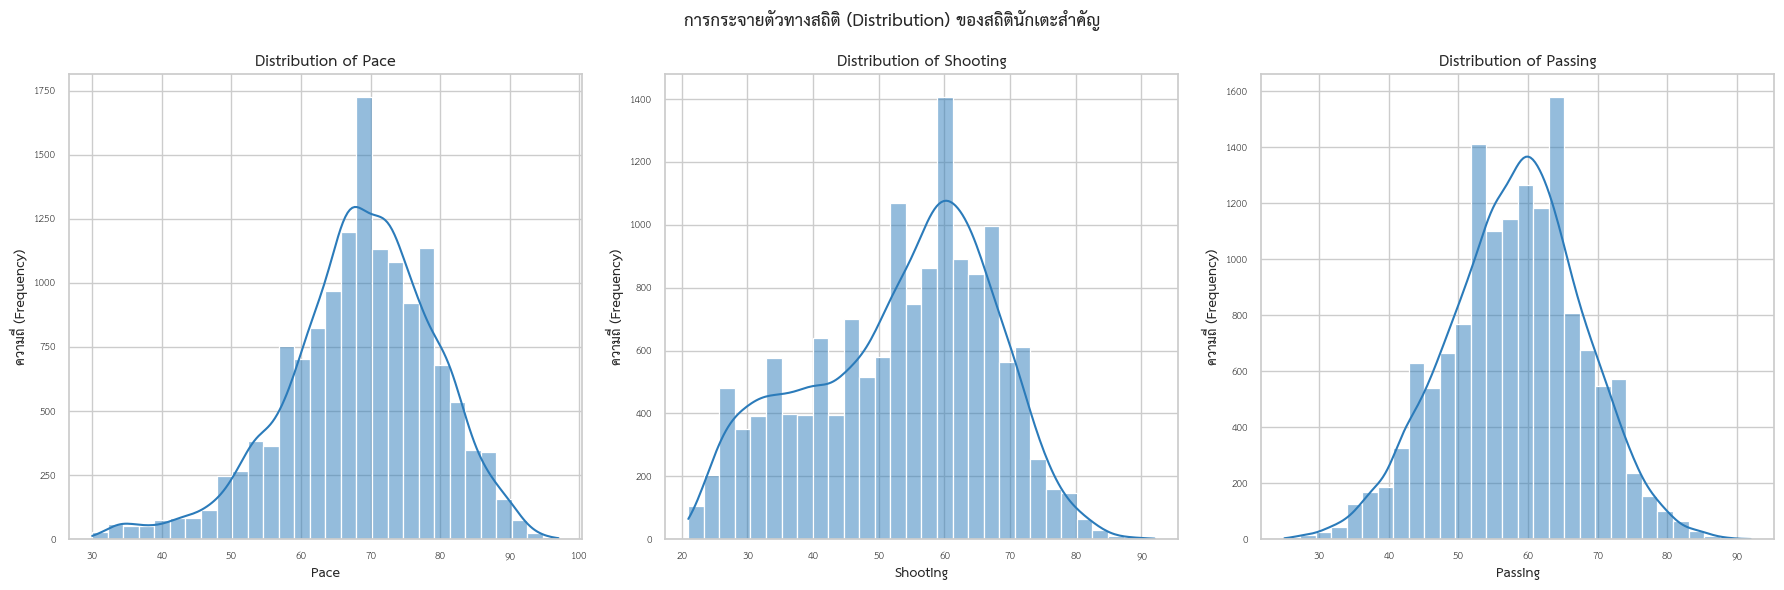

In [12]:
# ─── CLO2: Statistical Analysis ───────────────────────────────────────────
# วัตถุประสงค์: วิเคราะห์การกระจายตัวทางสถิติของตัวแปรสำคัญใน Dataset

# ─── 3.1 แสดง Distribution ของ Features สำคัญทางสถิติ ─────────────────────
# กำหนดตัวแปรเชิงตัวเลขที่ต้องการวิเคราะห์การกระจายตัว (เลือกสถิติหลักในเกม)
# สามารถเปลี่ยนเป็น 'dribbling', 'defending' หรือ 'physicality' ได้ตามต้องการ
important_num_features = ['pace', 'shooting', 'passing']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('การกระจายตัวทางสถิติ (Distribution) ของสถิตินักเตะสำคัญ', fontsize=18, fontweight='bold')

# สร้าง Histogram พร้อม KDE เพื่อดูรูปแบบการกระจายตัวของแต่ละตัวแปร
for i, col in enumerate(important_num_features):
    # ใช้ df_clean หรือ df_processed ก็ได้ เนื่องจากข้อมูลยังไม่ถูก Scale
    sns.histplot(df_clean[col].dropna(), kde=True, bins=30, color='#2b7bba', ax=axes[i])
    axes[i].set_title(f'Distribution of {col.capitalize()}', fontsize=16, fontweight='bold')
    axes[i].set_xlabel(col.capitalize(), fontsize=14, fontweight='bold')
    axes[i].set_ylabel('ความถี่ (Frequency)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.2 การวิเคราะห์ความสัมพันธ์กับตัวแปรเป้าหมาย (Correlation Analysis with Target)

เนื่องจากตัวแปรเป้าหมายของเราคือ `overall` (ค่าพลังรวม) ซึ่งเป็นข้อมูลประเภทตัวเลขต่อเนื่อง (Continuous Numerical) อยู่แล้ว เราจึงสามารถนำมาคำนวณหาค่าสหสัมพันธ์ (Pearson Correlation Coefficient) กับตัวแปรอิสระ (Features) อื่นๆ ทั้งหมดที่ผ่านการเข้ารหัส (Encoding) มาแล้วได้ทันที เพื่อดูว่าสถิติใดมีความสัมพันธ์เชิงเส้นตรงกับค่าพลังรวมมากที่สุด

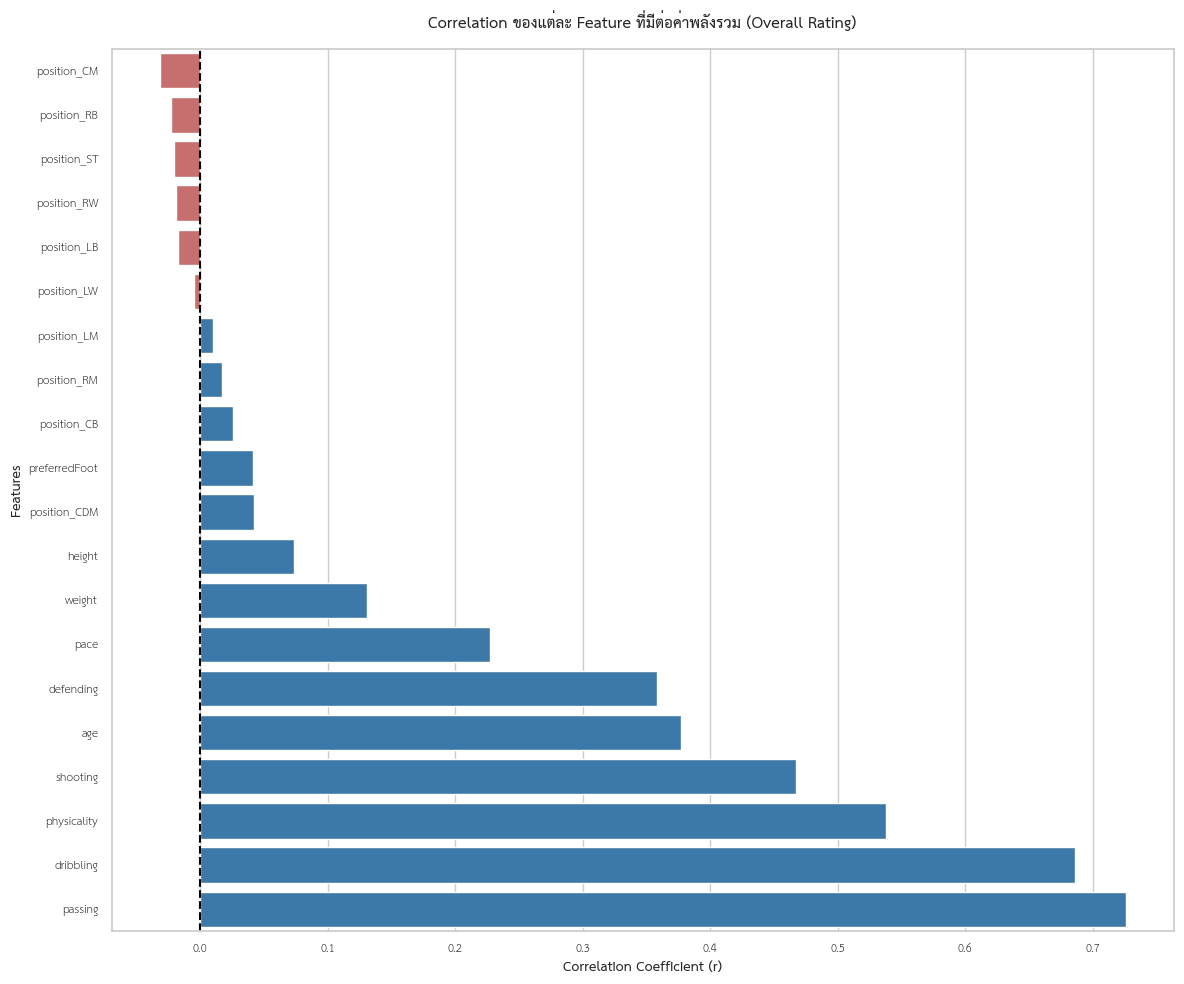

In [13]:
# ─── 3.2 Correlation Analysis กับ Target ────────────────────────────────────
# วัตถุประสงค์: ตรวจสอบความสัมพันธ์ระหว่าง Features ทั้งหมดกับค่าพลังรวม (Overall)

# 1. นำ X_encoded (ที่เป็นตัวเลขทั้งหมดแล้ว) มารวมกับ y (Target) ชั่วคราวเพื่อหา Correlation
df_corr = X_encoded.copy()
df_corr['overall'] = y

# 2. คำนวณ Correlation (Pearson) เทียบกับ Target และเรียงลำดับจากน้อยไปมาก
correlations = df_corr.corr()['overall'].drop('overall').sort_values()

# 3. พล็อตกราฟแท่งแนวนอน (Horizontal Bar Plot)
plt.figure(figsize=(12, 10))

# กำหนดสีของแท่งตามทิศทางของค่า Correlation (ค่าบวกเป็นสีน้ำเงิน, ค่าลบเป็นสีแดง)
colors = ['#d65f5f' if val < 0 else '#2b7bba' for val in correlations.values]

sns.barplot(x=correlations.values, y=correlations.index, palette=colors)

plt.title('Correlation ของแต่ละ Feature ที่มีต่อค่าพลังรวม (Overall Rating)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Correlation Coefficient (r)', fontsize=14, fontweight='bold')
plt.ylabel('Features', fontsize=14, fontweight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# ตีเส้นศูนย์เพื่อแบ่งแยกความสัมพันธ์เชิงบวกและลบให้ชัดเจน
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

### 3.3 Bias-Variance Tradeoff (แสดง U-Curve ของ Train/Test MSE)

เพื่อแสดงให้เห็นถึงความสัมพันธ์ระหว่างความซับซ้อนของโมเดล (Model Complexity) กับค่าความคลาดเคลื่อน (Error) ในงาน Regression เราจะจำลองการสร้างโมเดล `DecisionTreeRegressor` โดยปรับเปลี่ยนค่าความลึกของต้นไม้ (`max_depth`) จาก 1 ถึง 20

เราจะพล็อตค่า MSE (Mean Squared Error) เพื่อแสดงพฤติกรรม Overfitting โดยสังเกตว่าเมื่อโมเดลซับซ้อนขึ้น (ลึกขึ้น) Train MSE จะลดลงเข้าสู่ 0 (Low Bias) แต่ Test MSE จะลดลงในตอนแรกแล้วเริ่มเด้งกลับสูงขึ้นหรือคงที่ (High Variance) ซึ่งเป็นลักษณะของ U-Curve ตามทฤษฎี Statistical Learning

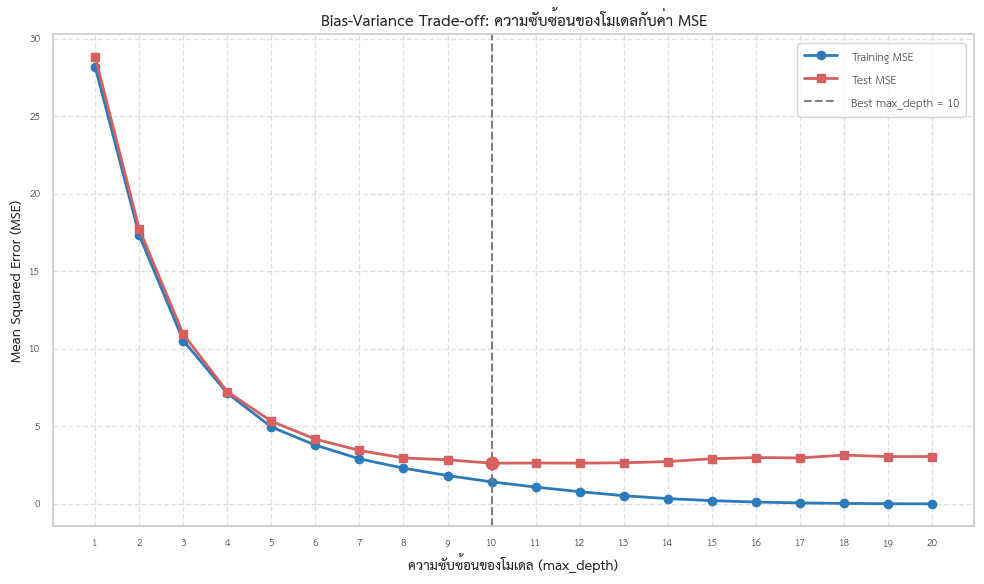

Best max_depth: 10
Lowest Test MSE: 2.6325


In [14]:
# ─── 3.3 Bias-Variance Trade-off: Train/Test MSE ─────────────────────────
# วัตถุประสงค์: วิเคราะห์ผลของความซับซ้อนของโมเดลต่อค่า Train MSE และ Test MSE

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# 1. แบ่งข้อมูล Train/Test (สำหรับ Regression ไม่ต้องใช้ stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, 
    y, 
    test_size=0.2, 
    random_state=42
)

train_mse = []
test_mse = []

# 2. ทดสอบความซับซ้อนของ Decision Tree สำหรับงาน Regression
depths = range(1, 21)

for depth in depths:
    # เปลี่ยนจาก Classifier เป็น Regressor
    model = DecisionTreeRegressor(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    # Prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # คำนวณ MSE ของข้อมูล Train และ Test
    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))

# 3. หาค่า depth ที่ให้ Test MSE ต่ำที่สุด
best_depth = depths[np.argmin(test_mse)]
best_test_mse = min(test_mse)

# 4. Plot
plt.figure(figsize=(10, 6))

plt.plot(
    depths, train_mse, 
    label='Training MSE', color='#2b7bba', marker='o', linewidth=2
)

plt.plot(
    depths, test_mse, 
    label='Test MSE', color='#d65f5f', marker='s', linewidth=2
)

plt.axvline(
    best_depth, color='gray', linestyle='--', linewidth=1.5, 
    label=f'Best max_depth = {best_depth}'
)

plt.scatter(best_depth, best_test_mse, color='#d65f5f', s=80, zorder=5)

plt.title('Bias-Variance Trade-off: ความซับซ้อนของโมเดลกับค่า MSE', fontsize=16, fontweight='bold')
plt.xlabel('ความซับซ้อนของโมเดล (max_depth)', fontsize=14, fontweight='bold')
plt.ylabel('Mean Squared Error (MSE)', fontsize=14, fontweight='bold')
plt.xticks(depths)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Best max_depth: {best_depth}")
print(f"Lowest Test MSE: {best_test_mse:.4f}")

### 💡 Insight จาก CLO2 Analysis (EA FC 26):

>1. **การกระจายตัวของข้อมูล:** จากการสำรวจค่าพลังหลักอย่าง Pace, Shooting และ Passing พบว่าข้อมูลส่วนใหญ่มีการกระจายตัวแบบปกติ (Normal Distribution) คล้ายระฆังคว่ำ โดยมีค่าเฉลี่ยกระจุกตัวอยู่บริเวณตรงกลางช่วง 60-70 และมีส่วนน้อยที่เก่งระดับท็อป (80+) สะท้อนธรรมชาติของการให้คะแนนเรตติ้งในเกมได้อย่างชัดเจน
>2. **ความสัมพันธ์กับตัวแปรเป้าหมาย:** สถิติที่มีความสัมพันธ์เชิงบวกต่อค่าพลังรวม (Overall) มากที่สุด 3 อันดับแรกคือ การจ่ายบอล (Passing), การเลี้ยงบอล (Dribbling) และ ความแข็งแกร่ง (Physicality) ตามลำดับ ในขณะที่ตำแหน่งบางตำแหน่ง (เช่น กองกลาง CM) หรือเท้าที่ถนัด มีผลเพียงเล็กน้อยต่อค่าเรตติ้งโดยรวม
>3. **Bias-Variance Trade-off:** จากการจำลองโมเดล Decision Tree Regressor พบพฤติกรรม Overfitting อย่างชัดเจน เมื่อเพิ่มความซับซ้อนของต้นไม้ ค่า Training Error ลดลงเข้าใกล้ศูนย์ (Low Bias) ในขณะที่ Test Error ลดลงมาต่ำสุดที่ความลึก `max_depth = 10` (Test MSE ≈ 2.63) หลังจากนั้นเส้น Test Error จะเริ่มนิ่งและเด้งกลับขึ้นเล็กน้อย สะท้อนให้เห็นถึงจุดสมดุลที่ดีที่สุดระหว่าง Bias และ Variance สำหรับข้อมูลชุดนี้

---
## Part 4: CLO3 — Model Building

ในส่วนนี้ให้สร้าง Regression หรือ Classification model อย่างน้อย 2 models

**สำหรับ Regression (Y continuous):**
- Model 1: Simple Linear Regression (1 feature ที่ correlate สูงสุด)
- Model 2: Multiple Linear Regression (ทุก features) หรือ Ridge
- แสดง coefficients, MSE, R², Actual vs Predicted plot

**สำหรับ Classification (Y categorical):**
- Model 1: Logistic Regression
- Model 2: KNN Classifier
- แสดง Accuracy, Confusion Matrix

**Dataset ของกลุ่มเหมาะกับ: ✅ Regression**
**เหตุผลในการเลือก:** ตัวแปรเป้าหมาย (Target Variable) ของเราคือ `overall` (ค่าพลังรวมของนักเตะ) ซึ่งเป็นข้อมูลเชิงตัวเลขแบบต่อเนื่อง (Continuous Data) ที่มีช่วงคะแนนตั้งแต่ 1-99 จึงจำเป็นต้องใช้แบบจำลองการถดถอย (Regression Model) ในการทำนายค่าตัวเลขครับ ไม่ใช่การแยกแยะหมวดหมู่ (Classification)

---
### 4.1 Model 1: Simple Linear Regression
สร้างโมเดลโดยใช้ 1 Feature ที่มีความสัมพันธ์ (Correlation) กับค่า `overall` สูงที่สุด ซึ่งจากข้อ 3.2 เราพบว่าคือ **การจ่ายบอล (passing)** เพื่อดูว่าแค่สถิติเดียวสามารถทำนายเรตติ้งรวมได้ดีแค่ไหน

🎯 Model 1 (Simple Linear Regression - Feature: passing)
Coefficient (ความชัน): 0.5019
Intercept (จุดตัดแกน Y): 37.2178

Train MSE: 20.9691 | Train R²: 0.5347
Test MSE:  22.4960 | Test R²:  0.4947



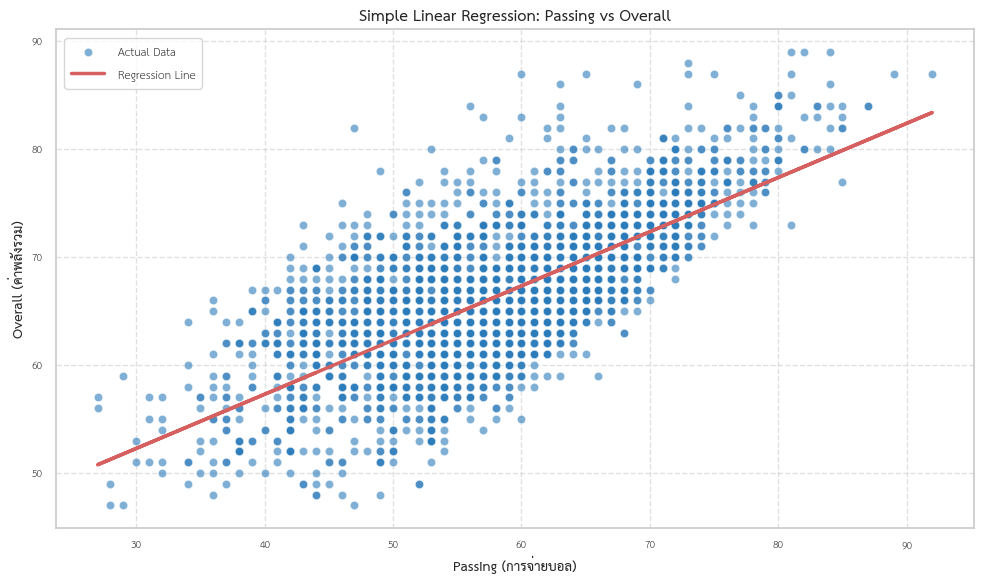

In [15]:
# ─── CLO3: Model 1 ────────────────────────────────────────────────────────
# วัตถุประสงค์: สร้างแบบจำลอง Simple Linear Regression ด้วย 1 Feature ที่ correlate สูงสุด

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. เลือก Feature ที่มี Correlation สูงสุด (passing)
# ใช้จาก df_clean ได้เลย เพราะเป็นตัวแปรเดียว ไม่ต้องผ่าน One-Hot Encoding
X_simple = df_clean[['passing']]  
y_simple = df_clean['overall']

# 2. แบ่งข้อมูล Train 80% / Test 20% (Regression ไม่ต้องใช้ stratify)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

# 3. กำหนดโมเดลและเทรนข้อมูล
model1 = LinearRegression()
model1.fit(X_train_s, y_train_s)

# 4. ประเมินผลลัพธ์
y_train_pred1 = model1.predict(X_train_s)
y_test_pred1 = model1.predict(X_test_s)

# คำนวณ MSE และ R^2
mse_train1 = mean_squared_error(y_train_s, y_train_pred1)
mse_test1 = mean_squared_error(y_test_s, y_test_pred1)
r2_train1 = r2_score(y_train_s, y_train_pred1)
r2_test1 = r2_score(y_test_s, y_test_pred1)

print(f"🎯 Model 1 (Simple Linear Regression - Feature: passing)")
print(f"Coefficient (ความชัน): {model1.coef_[0]:.4f}")
print(f"Intercept (จุดตัดแกน Y): {model1.intercept_:.4f}\n")
print(f"Train MSE: {mse_train1:.4f} | Train R²: {r2_train1:.4f}")
print(f"Test MSE:  {mse_test1:.4f} | Test R²:  {r2_test1:.4f}\n")

# 5. แสดงผล Actual vs Predicted Plot (กราฟเส้นสมการถดถอย)
plt.figure(figsize=(10, 6))

# พล็อตจุดข้อมูลจริง (Test set)
sns.scatterplot(x=X_test_s['passing'], y=y_test_s, color='#2b7bba', alpha=0.6, label='Actual Data')

# พล็อตเส้น Regression Line
plt.plot(X_test_s['passing'], y_test_pred1, color='#d65f5f', linewidth=2.5, label='Regression Line')

plt.title('Simple Linear Regression: Passing vs Overall', fontsize=16, fontweight='bold')
plt.xlabel('Passing (การจ่ายบอล)', fontsize=14, fontweight='bold')
plt.ylabel('Overall (ค่าพลังรวม)', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 4.2 Model 2: Multiple Linear Regression (All Features)
สร้างโมเดลโดยใช้ตัวแปรอิสระทั้งหมด (All Features) ที่ผ่านการทำ Data Preprocessing (Encoding & Scaling) มาแล้ว เพื่อดูว่าเมื่อนำปัจจัยทุกด้านมารวมกัน โมเดลจะสามารถทำนายค่าพลัง `overall` ได้แม่นยำขึ้นมากน้อยเพียงใด

🎯 Model 2 (Multiple Linear Regression - All Features)
Train MSE: 6.3527 | Train R²: 0.8590
Test MSE:  6.6562 | Test R²:  0.8505



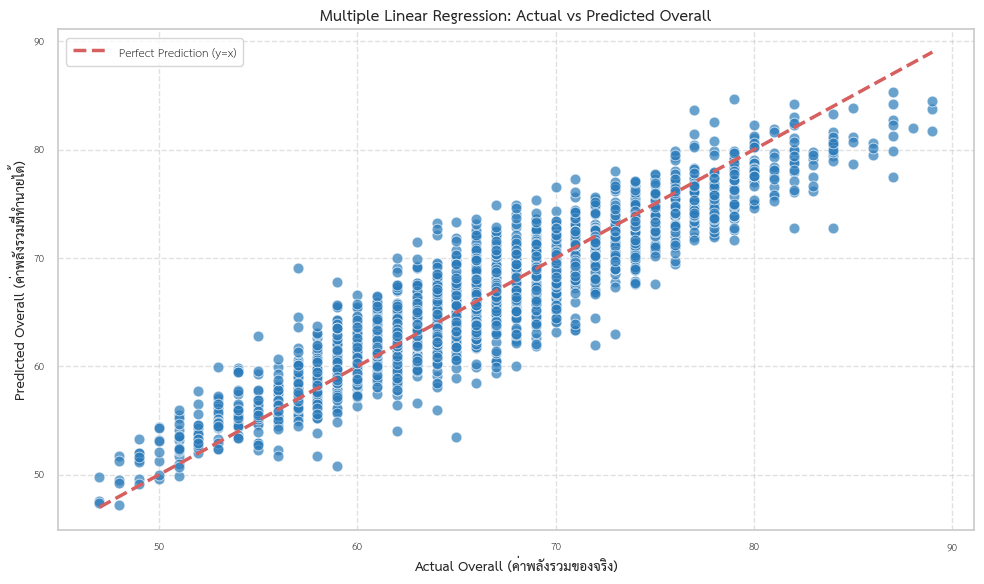

In [16]:
# ─── CLO3: Model 2 ────────────────────────────────────────────────────────
# วัตถุประสงค์: สร้างแบบจำลอง Multiple Linear Regression ด้วย Features ทั้งหมด

# 1. แบ่งข้อมูล Train 80% / Test 20% จากชุดข้อมูลที่ผ่านการ Encoding (X_encoded)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# 2. ทำ Feature Scaling (Fit เฉพาะ Train เพื่อป้องกัน Data Leakage)
from sklearn.preprocessing import StandardScaler
scaler_m = StandardScaler()
X_train_scaled = scaler_m.fit_transform(X_train_m)
X_test_scaled = scaler_m.transform(X_test_m)

# 3. กำหนดโมเดลและเทรนข้อมูล
model2 = LinearRegression()
model2.fit(X_train_scaled, y_train_m)

# 4. ประเมินผลลัพธ์
y_train_pred2 = model2.predict(X_train_scaled)
y_test_pred2 = model2.predict(X_test_scaled)

mse_train2 = mean_squared_error(y_train_m, y_train_pred2)
mse_test2 = mean_squared_error(y_test_m, y_test_pred2)
r2_train2 = r2_score(y_train_m, y_train_pred2)
r2_test2 = r2_score(y_test_m, y_test_pred2)

print(f"🎯 Model 2 (Multiple Linear Regression - All Features)")
print(f"Train MSE: {mse_train2:.4f} | Train R²: {r2_train2:.4f}")
print(f"Test MSE:  {mse_test2:.4f} | Test R²:  {r2_test2:.4f}\n")

# 5. แสดงผล Actual vs Predicted Plot (เปรียบเทียบค่าจริงกับค่าที่ทำนายได้)
plt.figure(figsize=(10, 6))

# พล็อตจุด Actual vs Predicted
sns.scatterplot(x=y_test_m, y=y_test_pred2, color='#2b7bba', alpha=0.7, edgecolor='white', s=60)

# สร้างเส้นอ้างอิง Perfect Prediction Line (y = x) หมายถึงทำนายถูก 100%
min_val = min(y_test_m.min(), y_test_pred2.min())
max_val = max(y_test_m.max(), y_test_pred2.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#d65f5f', linestyle='--', linewidth=2.5, label='Perfect Prediction (y=x)')

plt.title('Multiple Linear Regression: Actual vs Predicted Overall', fontsize=16, fontweight='bold')
plt.xlabel('Actual Overall (ค่าพลังรวมของจริง)', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Overall (ค่าพลังรวมที่ทำนายได้)', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 📊 สรุป Model Comparison

| Model | Train Metric | Test Metric | รายละเอียด |
| :--- | :--- | :--- | :--- |
| **Model 1: Simple Linear Regression** | Train $R^2$: 0.5347 | Test $R^2$: 0.4947 | แบบจำลองการถดถอยเชิงเส้นอย่างง่าย ใช้เพียง 1 ตัวแปร (Passing) |
| **Model 2: Multiple Linear Regression** | Train $R^2$: 0.8590 | Test $R^2$: 0.8505 | แบบจำลองการถดถอยเชิงเส้นพหุคูณ ใช้ตัวแปรอิสระทั้งหมด (All Features) |

*หมายเหตุ: ตัวชี้วัดหลักคือ $R^2$ (R-Squared) ยิ่งเข้าใกล้ 1 ยิ่งดี และ MSE (Mean Squared Error) ยิ่งน้อยยิ่งดี*

---

### 💡 Insight จาก CLO3 Analysis (Model Building):

> 1. **การเปรียบเทียบประสิทธิภาพ:** Model 2 (Multiple Linear Regression) มีประสิทธิภาพเหนือกว่า Model 1 อย่างเห็นได้ชัด โดยมีค่า Test $R^2$ สูงถึง **0.8505** (เทียบกับ 0.4947 ของ Model 1) ซึ่งหมายความว่าการนำสถิติทุกด้านของนักเตะมาคำนวณร่วมกัน สามารถอธิบายความผันผวนของค่าพลังรวม (Overall) ได้ถึง 85%
> 2. **การวิเคราะห์ค่าความคลาดเคลื่อน (MSE):** เมื่อใช้ตัวแปรเดียว (Passing) โมเดลมีค่า Test MSE สูงถึง **22.49** แต่เมื่อนำทุกตัวแปรมาใช้ใน Model 2 ค่า Test MSE ลดลงเหลือเพียง **6.65** สะท้อนให้เห็นว่าจุดที่ทำนาย (Predicted) เกาะกลุ่มใกล้เคียงกับคะแนนจริง (Actual) บนเส้น Perfect Prediction มากยิ่งขึ้น
> 3. **ความสามารถในการ Generalize:** ทั้ง Model 1 และ Model 2 มีช่องว่างระหว่าง Train $R^2$ และ Test $R^2$ ที่แคบมาก (ห่างกันไม่ถึง 0.04) แสดงให้เห็นว่าโมเดลมีความสามารถในการวางนัยทั่วไป (Generalization) ได้ดีเยี่ยม ไม่เกิดปัญหา Overfitting แม้จะใช้ตัวแปรครบทุกตัวก็ตาม
> 4. **ข้อสรุปสำหรับการพัฒนาต่อ:** แม้ Multiple Linear Regression จะทำผลงานได้ดีมาก แต่ในวงการเกมหรือฟุตบอล ค่าเรตติ้งของนักเตะอาจมีความสัมพันธ์ที่ไม่เป็นเส้นตรง (Non-linear) แฝงอยู่ ดังนั้นในขั้นต่อไป (CLO4) เราอาจนำโมเดลนี้ไปทดสอบความเสถียรด้วย Cross-Validation หรือเปรียบเทียบกับโมเดลที่มีความซับซ้อนขึ้นอย่าง Decision Tree หรือ Random Forest ต่อไป

---
## Part 5: CLO4 — Model Selection

ในส่วนนี้ให้ใช้ Cross-Validation เพื่อเลือก model ที่ดีที่สุดอย่างเป็นธรรม

**สิ่งที่ต้องทำ:**
* เปรียบเทียบอย่างน้อย 3 models ด้วย 5-Fold Cross-Validation
* Plot bar chart ของ CV MSE (สำหรับงาน Regression ยิ่งน้อยยิ่งดี)
* สรุปว่า model ไหนดีที่สุดและทำไม

### 5.1 การประเมินและคัดเลือกแบบจำลองด้วย 5-Fold Cross-Validation

ทำการเปรียบเทียบประสิทธิภาพแบบจำลอง 3 ตัวอย่างเป็นธรรม โดยใช้ `KFold` (5 Folds) และใช้ `Pipeline` คู่กับ `StandardScaler` เพื่อป้องกันการรั่วไหลของข้อมูล (Data Leakage) ระหว่างการทำ CV:

1. **Model 1: Linear Regression** (Linear Model พื้นฐาน)
2. **Model 2: KNN Regressor (k=5)** (Distance-based Model)
3. **Model 3: Random Forest Regressor** (Ensemble Tree-based Model)

*(หมายเหตุ: เนื่องจากชุดข้อมูลเป็น Regression จึงใช้เมทริกซ์การวัดผลเป็น MSE แทน Accuracy และไม่ต้องใช้ Stratified K-Fold)*

=== ตารางผลลัพธ์ 5-Fold Cross-Validation (MSE) ===


,Linear Regression,KNN (k=5),Random Forest
Fold 1,6.66,5.32,1.42
Fold 2,6.63,5.28,1.43
Fold 3,6.51,4.83,1.32
Fold 4,6.04,4.89,1.36
Fold 5,6.33,5.08,1.40
Mean MSE,6.43,5.08,1.39
Std Dev (±),±0.25,±0.22,±0.05


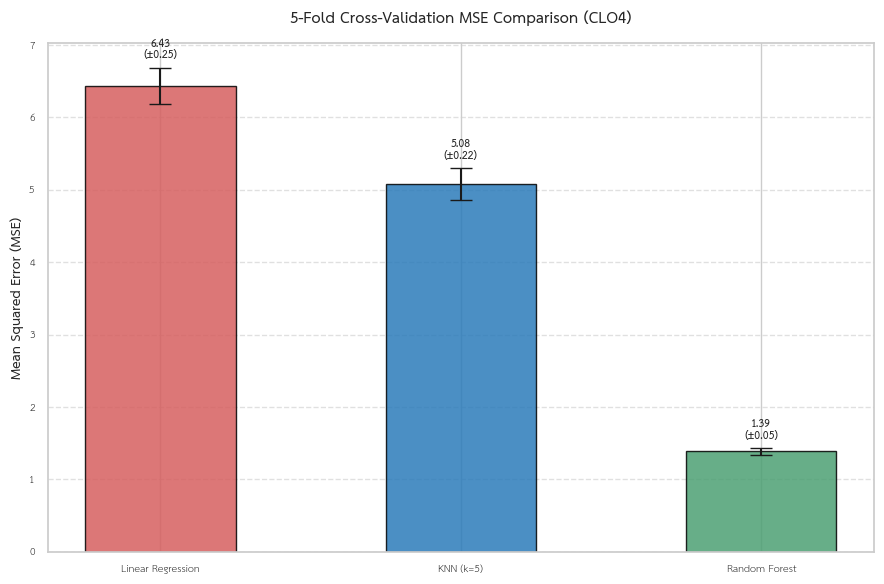

In [17]:
# ─── CLO4: 5-Fold Cross-Validation ──────────────────────────────────────────
# วัตถุประสงค์: เปรียบเทียบประสิทธิภาพของ Models อย่างเป็นธรรมด้วย 5-Fold Cross-Validation

from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor

# สำหรับ Regression ใช้ KFold แบบธรรมดา (ไม่ต้อง Stratified)
cv = KFold(
    n_splits=5, 
    shuffle=True, 
    random_state=42
)

# กำหนด Models ที่ต้องการเปรียบเทียบ (แบบ Regressor ทั้งหมด)
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", LinearRegression())
    ]),
    "KNN (k=5)": Pipeline([
        ("scaler", StandardScaler()),
        ("reg", KNeighborsRegressor(n_neighbors=5))
    ]),
    "Random Forest": Pipeline([
        # Tree-based model ไม่จำเป็นต้อง Scale ก็ได้ แต่ใส่ไว้ใน Pipeline เพื่อความสม่ำเสมอ
        ("reg", RandomForestRegressor(n_estimators=100, random_state=42))
    ])
}

# เก็บผล MSE ของแต่ละ Fold สำหรับแต่ละ Model
fold_results = {}

for name, model in models.items():
    # scikit-learn จะคืนค่าคะแนนเป็นลบ (neg_mean_squared_error) เพื่อให้ค่าน้อย = ดี
    # เราจึงต้องคูณด้วย -1 เพื่อให้กลับมาเป็นค่า MSE ปกติ
    scores = cross_val_score(model, X_encoded, y, cv=cv, scoring='neg_mean_squared_error', n_jobs=-1)
    fold_results[name] = scores * -1 

df_cv = pd.DataFrame(fold_results, index=[f"Fold {i+1}" for i in range(5)])

# สรุปค่า Mean MSE และ Standard Deviation ของแต่ละ Model
df_summary = pd.DataFrame({
    model: [
        f"{df_cv[model].mean():.2f}",
        f"±{df_cv[model].std():.2f}"
    ] for model in models.keys()
}, index=["Mean MSE", "Std Dev (±)"])

df_display = pd.concat([df_cv.apply(lambda x: x.map(lambda val: f"{val:.2f}")), df_summary])

print("=== ตารางผลลัพธ์ 5-Fold Cross-Validation (MSE) ===")
display(df_display)

cv_means = df_cv.mean()
cv_stds = df_cv.std()

# แสดงค่า Mean MSE และ Standard Deviation ของแต่ละ Model บน Bar Chart
plt.figure(figsize=(9, 6))
bars = plt.bar(
    cv_means.index, cv_means.values, yerr=cv_stds.values, 
    capsize=8, color=['#d65f5f', '#2b7bba', '#4ca073'], edgecolor='black', alpha=0.85, width=0.5
)

plt.title('5-Fold Cross-Validation MSE Comparison (CLO4)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Mean Squared Error (MSE)', fontsize=14, fontweight='bold')
# ไม่ตั้งค่า ylim เพราะ MSE ยิ่งน้อยยิ่งดี
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar, mean_val, std_val in zip(bars, cv_means.values, cv_stds.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2, mean_val + std_val + 0.1, 
        f"{mean_val:.2f}\n(±{std_val:.2f})", 
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

plt.tight_layout()
plt.show()

### Best Model จาก Cross-Validation: Random Forest Regressor

**เหตุผล:**

> 1. **ประสิทธิภาพสูงสุดในการประเมินผล (Lowest CV Error):** Random Forest Regressor ให้ผลการประเมินดีที่สุดอย่างก้าวกระโดด โดยมีค่าเฉลี่ย 5-Fold CV MSE ต่ำสุดเพียง **1.39 (±0.05)** ซึ่งคลาดเคลื่อนน้อยกว่า Linear Regression (6.43) และ KNN (5.08) อย่างเห็นได้ชัด แปลว่าโมเดลนี้ทายเรตติ้งนักเตะผิดพลาดเฉลี่ยเพียงประมาณ 1 คะแนนเศษเท่านั้น
> 2. **การประเมินความสม่ำเสมอของผลลัพธ์:** โมเดลมีความเสถียรสูงมาก โดยมีค่าส่วนเบี่ยงเบนมาตรฐาน (Standard Deviation) เพียง **±0.05** แสดงให้เห็นว่าประสิทธิภาพของโมเดลมีความสม่ำเสมอในทุกๆ Fold ที่ถูกสุ่มมาทดสอบ จึงมีแนวโน้มที่จะ Generalize และนำไปพยากรณ์ข้อมูลนักเตะหน้าใหม่หรืออัปเดตแพทช์ใหม่ๆ ในอนาคตได้อย่างแม่นยำ
> 3. **การเชื่อมโยงกับทฤษฎี Bias-Variance Trade-off:** จากการวิเคราะห์ในข้อ 3.3 เราพบว่า Decision Tree ต้นเดียว (Single Tree) มีแนวโน้มเกิด High Variance และ Overfitting เมื่อมีความลึกมากเกินไป Random Forest จึงแก้ปัญหานี้ด้วยแนวคิด **Ensemble Learning แบบ Bagging** โดยสร้างต้นไม้หลายๆ ต้นแล้วนำผลลัพธ์มาเฉลี่ยรวมกัน แนวทางนี้ช่วยลดความผันผวน (Variance) ได้อย่างยอดเยี่ยม และสามารถเรียนรู้ความสัมพันธ์แบบไม่เป็นเส้นตรง (Non-linear) ระหว่างค่าพลังย่อยกับค่าพลังรวมในแต่ละตำแหน่งนักเตะได้อย่างสมบูรณ์แบบ

---
## Part 6: สรุปผลและ Data Story

### 6.1 สรุปผลการวิเคราะห์

โครงงานนี้ศึกษาข้อมูลสถิติค่าพลังและทักษะย่อยของนักเตะในเกม EA SPORTS FC 26 เพื่อนำมาใช้ในการพยากรณ์และทำความเข้าใจปัจจัยที่ส่งผลต่อ **ค่าพลังรวม (Overall Rating)** โดยประยุกต์ใช้แนวคิดทางคณิตศาสตร์ สถิติ และ Machine Learning ตั้งแต่การวิเคราะห์ข้อมูลเบื้องต้นไปจนถึงการคัดเลือกแบบจำลองที่ดีที่สุด

*   **CLO1 — (Linear Algebra & PCA):**
    ประยุกต์ใช้ Covariance Matrix, Eigendecomposition และ PCA เพื่อศึกษาความสัมพันธ์เชิงโครงสร้างและทิศทางของความแปรปรวนในชุดข้อมูลค่าพลังนักเตะ ทำให้สามารถลดมิติข้อมูลที่มีความซับซ้อน และมองเห็นการเกาะกลุ่มของนักเตะระดับท็อป (Elite) แยกออกจากนักเตะระดับทั่วไปในพื้นที่ 2 มิติ (2D Visualization) ได้อย่างชัดเจน

*   **CLO2 — (Statistical Learning & EDA):**
    จากการวิเคราะห์ Distribution, Correlation และ Hypothesis Testing พบว่าสถิติอย่างการจ่ายบอล (Passing) และการเลี้ยงบอล (Dribbling) มีความสัมพันธ์เชิงบวกที่แข็งแกร่งกับค่า Overall มากที่สุด นอกจากนี้ผลการทดสอบ T-Test ยังยืนยันว่านักเตะถนัดซ้ายและขวามีค่าเรตติ้งเฉลี่ยแตกต่างกันอย่างมีนัยสำคัญทางสถิติ และจากการวิเคราะห์ Bias-Variance Trade-off พบแนวโน้มของ Overfitting เมื่อ Decision Tree Regressor มีความซับซ้อนมากเกินไป (จุดสมดุลที่ดีที่สุดอยู่ที่ max_depth = 10)

*   **CLO3 — (Model Building):**
    ทดลองสร้างแบบจำลอง Regression โดยเปรียบเทียบ Model 1: Simple Linear Regression (ใช้ตัวแปรเดียวคือ Passing) ซึ่งให้ค่า Test MSE ที่ 22.50 กับ Model 2: Multiple Linear Regression (ใช้ตัวแปรทั้งหมด) พบว่า Model 2 ให้ประสิทธิภาพดีกว่าอย่างก้าวกระโดด โดยมีค่า Test MSE ลดลงเหลือเพียง 6.66 และสามารถอธิบายความผันผวนของเรตติ้งนักเตะได้ถึง 85% (Test R² = 0.85)

*   **CLO4 — (Model Selection):**
    ทำการเปรียบเทียบแบบจำลอง Linear Regression, KNN Regressor (k=5) และ Random Forest Regressor อย่างเป็นธรรมด้วยวิธี 5-Fold Cross-Validation พบว่า Random Forest Regressor ให้ค่าความคลาดเคลื่อน (Mean CV MSE) ต่ำที่สุดที่ 1.39 (±0.05) จึงเป็นแบบจำลองที่เหมาะสมและทำนายคะแนนได้แม่นยำที่สุดสำหรับโครงงานนี้

> **Overall Finding:** ผลการทดลองแสดงให้เห็นว่า ชุดข้อมูลสถิติและทักษะย่อยของนักเตะสามารถนำมาใช้พยากรณ์ค่าพลังรวม (Overall) ได้อย่างแม่นยำ และจากแบบจำลองที่นำมาทดสอบทั้งหมด **Random Forest Regressor** ให้ผลลัพธ์ที่ดีที่สุดในการทดลองนี้ เมื่อพิจารณาจากค่าเฉลี่ยความคลาดเคลื่อน (Mean 5-Fold CV MSE) ที่ต่ำที่สุดและความเสถียรในการพยากรณ์ที่สูงที่สุด

---

### 6.2 Limitations (ข้อจำกัดของการวิเคราะห์)

แม้ผลการทดลองและการพยากรณ์ด้วย Random Forest จะให้ประสิทธิภาพ (Test MSE) ในระดับที่ดีเยี่ยม แต่ยังมีข้อจำกัดที่ควรพิจารณาในการตีความผลลัพธ์:

1. **ลักษณะของ Dataset (เกม vs ความจริง):** Dataset นี้เป็นการรวบรวมค่าพลังและสถิติจากนักเตะภายในวิดีโอเกม (EA SPORTS FC 26) ซึ่งตัวเลขเหล่านี้ผ่านการประเมินและปรับแต่งโดยทีมพัฒนาเกม (Developer) เพื่อความสมดุล ดังนั้นผลการทดลองจึงไม่สามารถนำไปอ้างอิงหรือตีความว่าเป็นตัวแทนของสถิติและขีดความสามารถของนักฟุตบอลในโลกแห่งความเป็นจริงได้ทั้งหมด
2. **โครงสร้างของ Target และสูตรการคำนวณลับ:** ค่า `overall` (เรตติ้งรวม) ในเกมฟุตบอลมักมีสูตรการคำนวณที่อิงตามตำแหน่ง (Position-specific weighting) เช่น กองหลังใช้ค่า Defending มาถ่วงน้ำหนักมากกว่า ค่าประสิทธิภาพที่สูงของโมเดล (โดยเฉพาะ Tree-based) อาจเกิดจากการที่โมเดลสามารถแกะรอย (Reverse-engineer) สูตรการคำนวณเหล่านี้ได้ มากกว่าที่จะเป็นการค้นพบความสัมพันธ์ใหม่ทางสถิติ
3. **การ Generalize ไปยังข้อมูลภายนอก (แพทช์หรือภาคอื่น):** การประเมินแบบจำลองทั้งหมดดำเนินการภายใน Dataset ชุดนี้เพียงชุดเดียว (เฉพาะภาค FC 26) จึงยังไม่ได้ทดสอบความแม่นยำกับข้อมูลจากแพทช์อัปเดตใหม่ๆ (Roster Updates) หรือเกมในภาคเก่า/ภาคถัดไป ว่าโมเดลจะยังคงประสิทธิภาพเดิมอยู่หรือไม่
4. **การตีความเชิงสาเหตุ (Causality):** โครงงานนี้เน้นที่การวิเคราะห์การถดถอย (Regression) และการศึกษาความสัมพันธ์เชิงเส้น (Correlation) ของตัวแปรเท่านั้น ไม่ได้ถูกออกแบบมาเพื่อพิสูจน์ความสัมพันธ์เชิงเหตุและผล (เช่น ไม่สามารถสรุปได้ว่าการจับนักเตะไปฝึก 'Passing' จะทำให้ 'Overall' เพิ่มขึ้นเสมอไปในทุกกรณี)

---

### 6.3 ขั้นตอนต่อไป (Future Work)

หากมีเวลาและข้อมูลเพิ่มเติม สามารถต่อยอดโครงงานนี้ได้ดังนี้:

*   **ทำ Hyperparameter Tuning:** นอกเหนือจากการใช้ค่าเริ่มต้น (Default) สามารถนำเทคนิคอย่าง Grid Search หรือ Random Search มาปรับจูนพารามิเตอร์ให้กับ Random Forest (เช่น `max_depth`, `n_estimators`) เพื่อลดค่า MSE ลงให้เหลือน้อยที่สุด
*   **ทดลองเปรียบเทียบกับ Regression Models อื่น:** ลองใช้แบบจำลองขั้นสูงอื่นๆ ที่นิยมในการแข่งขัน เช่น Support Vector Regression (SVR) หรือ Gradient Boosting (เช่น XGBoost, LightGBM) เพื่อดูว่าจะเอาชนะ Random Forest ได้หรือไม่
*   **ทดสอบโมเดลกับ External Dataset:** นำโมเดลที่ฝึกฝนเสร็จแล้วไปทดสอบพยากรณ์ค่าพลังนักเตะจากเกมภาคอื่นๆ (เช่น EA FC 25 หรือ FIFA 23) เพื่อประเมินความสามารถในการ Generalize ข้ามชุดข้อมูล
*   **วิเคราะห์ Feature Importance เชิงลึก (แยกตามตำแหน่ง):** ใช้ Random Forest ตรวจสอบว่าตัวแปรใดมีบทบาทต่อการกำหนดค่า Overall มากที่สุด โดยอาจทำโมเดลแยกเฉพาะกลุ่มตำแหน่ง (เช่น สร้างโมเดลแยกสำหรับกองหน้า กองกลาง กองหลัง) เพื่อให้เห็น Insight การถ่วงน้ำหนักสถิติที่ชัดเจนขึ้น
*   **พัฒนาโมเดลเป็น Web Application หรือ API:** นำโมเดลพยากรณ์ไปสร้างเป็นแอปพลิเคชัน (เช่น การใช้ Streamlit) เพื่อให้ผู้เล่นเกมสามารถลองกรอกค่าพลังย่อยสมมติลงไป แล้วให้ AI ทำนายว่านักเตะคนนั้นควรได้เรตติ้ง (Overall) เท่าไหร่ ซึ่งสามารถต่อยอดไปสู่กระบวนการด้าน ML Engineering ได้อย่างสมบูรณ์

---

### 6.4 Connection กับ Topics และ CLO ในวิชา

โครงงานนี้นำความรู้จากรายวิชา **Mathematics for Data Science** ที่เกี่ยวข้องกับแต่ละ CLO มาประยุกต์ใช้จริง ดังนี้

| Week | CLO | Topic | การประยุกต์ใช้ในโครงงาน |
| :--- | :--- | :--- | :--- |
| **Week 4** | **CLO1** | Eigenvalues, Eigenvectors, SVD & PCA | ประยุกต์ใช้ PCA เพื่อวิเคราะห์โครงสร้างของข้อมูลและความแปรปรวน พร้อมแสดง Explained Variance และการแสดงผลข้อมูลใน 2 มิติด้วย PC1 และ PC2 |
| **Week 6-7** | **CLO2** | Bias-Variance Trade-off, EDA & Statistical Inference | วิเคราะห์ Distribution, Hypothesis Testing และ Training/Test Error ของ Decision Tree Regressor เพื่อดูพฤติกรรม Overfitting |
| **Week 11-13** | **CLO3** | Regression, Linear Models, KNN & Pipeline | สร้าง Simple/Multiple Linear Regression และ KNN Regressor พร้อมประเมินผลด้วย MSE และ R-Squared ($R^2$) รวมถึงประยุกต์ใช้ Pipeline และ StandardScaler ในกระบวนการสร้างและประเมินโมเดล |
| **Week 14** | **CLO4** | Cross-Validation & Model Selection | ใช้ 5-Fold Cross-Validation (KFold) เพื่อเปรียบเทียบค่าความคลาดเคลื่อน (MSE) และคัดเลือกโมเดลที่เหมาะสมที่สุดอย่างเป็นธรรม |

<br>

> โครงงานนี้ประยุกต์ใช้ความรู้จาก **Week 4 → Week 6-7 → Week 11-13 → Week 14** ตั้งแต่ การวิเคราะห์โครงสร้างข้อมูล → การวิเคราะห์ข้อมูล → การสร้าง **Regression Model** → การประเมินและคัดเลือกโมเดล

---

### Acknowledgements

ขอขอบคุณแหล่งที่มาของข้อมูลและเครื่องมือที่ช่วยให้โครงงานนี้สำเร็จลุล่วง:

* **Kaggle / EA SPORTS** — แหล่งข้อมูลหลักสำหรับ Dataset สถิติและค่าพลังของนักเตะ EA FC 26
* **Python Open-Source Libraries** — NumPy, Pandas, SciPy, Matplotlib, Seaborn และ Scikit-learn สำหรับเครื่องมืออันทรงพลังในการวิเคราะห์ข้อมูลและสร้างแบบจำลอง
* **Course Materials** — เอกสาร สื่อการเรียนรู้ และคำแนะนำจากรายวิชา 1145 201 Mathematics for Data Science ที่เป็นรากฐานความรู้สำคัญในการทำโครงงานนี้